<a href="https://colab.research.google.com/github/AnkitaPathak06/ankita-portfolio/blob/main/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Insurance Claim Fraud Detection**Colab setup:** File → Upload notebook → pick this file. Click the 📁 icon on the left and upload `synthetic_health_claims.csv`. Then Runtime → Run all.

## 1. Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Read the CSV file

In [ ]:
df = pd.read_csv('/content/Insurance Claims.csv')

## 3. Check the size of the data

In [ ]:
df.shape

(20100, 30)

## 4. Look at the first few rows

In [ ]:
df.head()

,Patient_ID,Policy_Number,Claim_ID,Claim_Date,Service_Date,Policy_Expiration_Date,Claim_Amount,Patient_Age,Patient_Gender,Patient_City,...,Discharge_Type,Length_of_Stay_Days,Service_Type,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles,Claim_Submitted_Late,Is_Fraudulent
0,67349080,XAI956194550,18874,2021-06-16,2021-05-01,2024-11-20,462337.48,28,Female,Houston,...,Rehab/Skilled Nursing,47,Inpatient,3440.06,824.59,0,16,939.08,True,False
1,85973291,XAI215993963,8762,2025-01-19,2025-01-17,2029-04-07,1883481.30,40,Other,Washington,...,Deceased,0,Outpatient,3618.40,851.43,0,6,170.40,False,True
2,62454860,XAI146653263,1920,2023-05-05,2023-03-24,2024-09-04,1500658.89,90,Female,Seattle,...,Deceased,0,Pharmacy,2442.41,616.23,0,2,549.38,True,False
3,58632240,XAI216596381,1316,2021-11-07,2021-11-02,2025-12-24,572237.61,49,Other,Fort Worth,...,Deceased,0,Pharmacy,587.78,459.33,0,2,396.49,False,True
4,96347311,XAI056900359,17039,2024-03-25,2024-02-18,2028-07-30,2088293.84,24,Female,New York,...,Deceased,0,Emergency Room,3047.55,847.40,0,15,865.87,True,False


## 5. Check the column types

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20100 entries, 0 to 20099
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Patient_ID                          20100 non-null  int64  
 1   Policy_Number                       20100 non-null  object 
 2   Claim_ID                            20100 non-null  int64  
 3   Claim_Date                          20100 non-null  object 
 4   Service_Date                        20100 non-null  object 
 5   Policy_Expiration_Date              20100 non-null  object 
 6   Claim_Amount                        20100 non-null  float64
 7   Patient_Age                         20100 non-null  int64  
 8   Patient_Gender                      20100 non-null  object 
 9   Patient_City                        20100 non-null  object 
 10  Patient_State                       20100 non-null  object 
 11  Hospital_ID                         20100

## 6. Check for missing values

In [ ]:
df.isnull().sum()

,0
Patient_ID,0
Policy_Number,0
Claim_ID,0
Claim_Date,0
Service_Date,0
Policy_Expiration_Date,0
Claim_Amount,0
Patient_Age,0
Patient_Gender,0
Patient_City,0


## 7. Check the summary statistics

In [ ]:
df.describe()

,Patient_ID,Claim_ID,Claim_Amount,Patient_Age,Hospital_ID,Procedure_Code,Number_of_Procedures,Length_of_Stay_Days,Deductible_Amount,CoPay_Amount,Number_of_Previous_Claims_Patient,Number_of_Previous_Claims_Provider,Provider_Patient_Distance_Miles
count,2.010000e+04,20100.000000,2.010000e+04,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000,20100.000000
mean,5.528158e+07,10005.580348,1.245349e+06,45.104925,500.204179,92463.849851,5.510249,4.975821,2508.487758,499.665796,0.000299,10.027910,499.480532
std,2.606038e+07,5774.135663,6.983001e+05,26.300942,288.437500,8151.470654,2.882847,13.239804,1443.579069,288.397727,0.017275,6.622332,289.745360
min,1.000265e+07,1.000000,5.516780e+03,0.000000,1.000000,71045.000000,1.000000,0.000000,0.030000,0.020000,0.000000,0.000000,0.020000
25%,3.266819e+07,5005.750000,6.674103e+05,22.000000,251.000000,93040.000000,3.000000,0.000000,1251.440000,248.800000,0.000000,5.000000,246.380000
50%,5.551009e+07,10008.500000,1.221707e+06,45.000000,500.000000,93571.000000,6.000000,0.000000,2508.875000,499.950000,0.000000,10.000000,498.410000
75%,7.814105e+07,15011.250000,1.835603e+06,68.000000,752.000000,99204.000000,8.000000,0.000000,3755.080000,750.040000,0.000000,15.000000,751.000000
max,9.998440e+07,20000.000000,2.499689e+06,90.000000,1000.000000,99284.000000,10.000000,60.000000,4999.870000,999.880000,1.000000,34.000000,999.980000


## 8. Count how many claims are fraud

In [ ]:
df['Is_Fraudulent'].value_counts()

,count
Is_Fraudulent,
False,15089
True,5011


## 9. See it as a percentage75% are not fraud. This is our baseline. The model must beat 75% accuracy.

In [ ]:
df['Is_Fraudulent'].value_counts(normalize=True)

,proportion
Is_Fraudulent,
False,0.750697
True,0.249303


## 10. Plot the fraud count

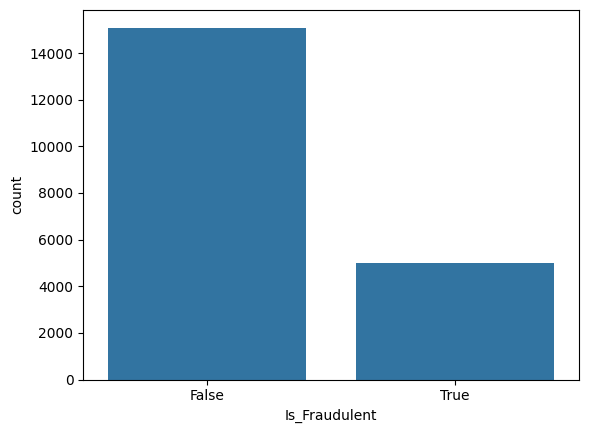

In [ ]:
sns.countplot(x='Is_Fraudulent', data=df)
plt.show()

## 11. Store the overall fraud rateWe use this as a reference line in the next plots.

In [ ]:
average = df['Is_Fraudulent'].mean()

## 12. Fraud rate by Provider Type

In [ ]:
rate = df.groupby('Provider_Type')['Is_Fraudulent'].mean()

## 13. Plot it

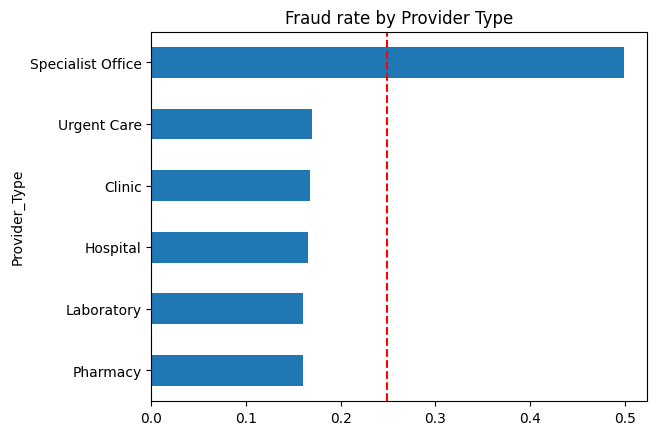

In [ ]:
rate.sort_values().plot(kind='barh')
plt.axvline(average, color='red', linestyle='--')
plt.title('Fraud rate by Provider Type')
plt.show()

## 14. Fraud rate by Provider Specialty

In [ ]:
rate = df.groupby('Provider_Specialty')['Is_Fraudulent'].mean()

## 15. Plot it

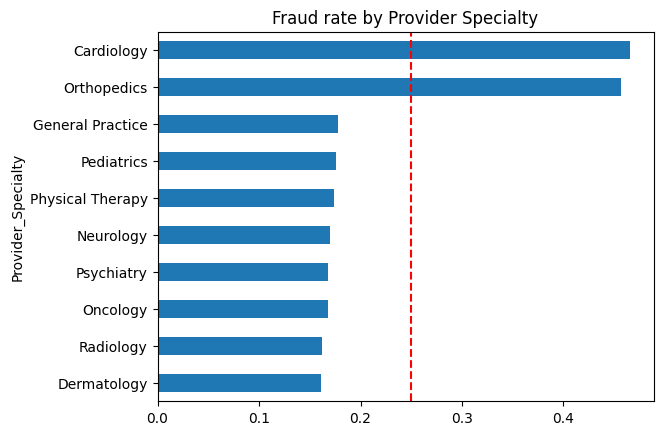

In [ ]:
rate.sort_values().plot(kind='barh')
plt.axvline(average, color='red', linestyle='--')
plt.title('Fraud rate by Provider Specialty')
plt.show()

## 16. Fraud rate by Admission Type

In [ ]:
rate = df.groupby('Admission_Type')['Is_Fraudulent'].mean()

## 17. Plot it

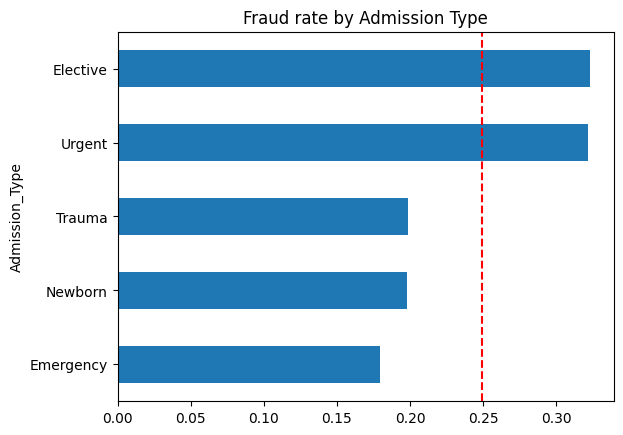

In [ ]:
rate.sort_values().plot(kind='barh')
plt.axvline(average, color='red', linestyle='--')
plt.title('Fraud rate by Admission Type')
plt.show()

## 18. Fraud rate by Service Type

In [ ]:
rate = df.groupby('Service_Type')['Is_Fraudulent'].mean()

## 19. Plot it

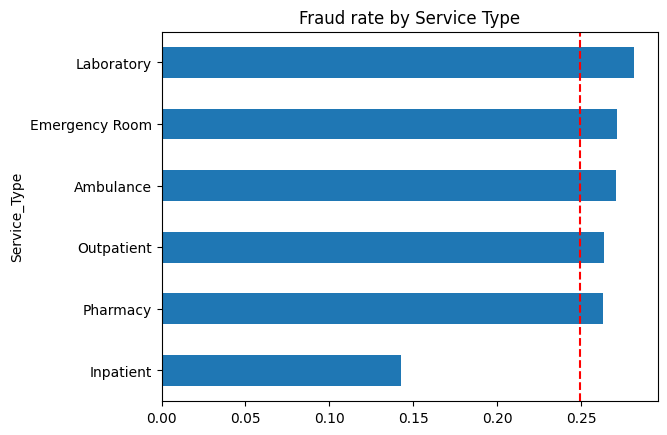

In [ ]:
rate.sort_values().plot(kind='barh')
plt.axvline(average, color='red', linestyle='--')
plt.title('Fraud rate by Service Type')
plt.show()

**Findings so far**- Specialist Office = 50% fraud, others around 16%- Cardiology and Orthopedics = 46%, others around 17%- Elective and Urgent admissions are riskier than Emergency

## 20. Fraud rate by Claim Amount. We cut the column into 4 equal groups and check each group.

In [ ]:
groups = pd.qcut(df['Claim_Amount'], 4)
df.groupby(groups, observed=True)['Is_Fraudulent'].mean()

,Is_Fraudulent
Claim_Amount,
"(5516.7789999999995, 667410.282]",0.143682
"(667410.282, 1221706.875]",0.347861
"(1221706.875, 1835603.445]",0.288756
"(1835603.445, 2499688.55]",0.216915


## 21. Fraud rate by Number of Procedures

In [ ]:
groups = pd.qcut(df['Number_of_Procedures'], 4)
df.groupby(groups, observed=True)['Is_Fraudulent'].mean()

,Is_Fraudulent
Number_of_Procedures,
"(0.999, 3.0]",0.214887
"(3.0, 6.0]",0.130653
"(6.0, 8.0]",0.286398
"(8.0, 10.0]",0.436967


## 22. Fraud rate by Distance

In [ ]:
groups = pd.qcut(df['Provider_Patient_Distance_Miles'], 4)
df.groupby(groups, observed=True)['Is_Fraudulent'].mean()

,Is_Fraudulent
Provider_Patient_Distance_Miles,
"(0.019, 246.38]",0.185871
"(246.38, 498.41]",0.178109
"(498.41, 751.0]",0.318345
"(751.0, 999.98]",0.314889


## 23. Fraud rate by Patient Age

In [ ]:
groups = pd.qcut(df['Patient_Age'], 4)
df.groupby(groups, observed=True)['Is_Fraudulent'].mean()

,Is_Fraudulent
Patient_Age,
"(-0.001, 22.0]",0.250787
"(22.0, 45.0]",0.254657
"(45.0, 68.0]",0.241555
"(68.0, 90.0]",0.250307


More procedures = more fraud. Longer distance = more fraud. Age makes no difference.

## 24. Count duplicate rows

In [ ]:
df.duplicated().sum()

np.int64(28)

## 25. Remove the duplicates

In [ ]:
df = df.drop_duplicates()

## 26. Check the size again

In [ ]:
df.shape

(20072, 30)

## 27. Convert the date columns to date typeRight now they are stored as text, so we cannot subtract them.

In [ ]:
df['Claim_Date'] = pd.to_datetime(df['Claim_Date'])
df['Service_Date'] = pd.to_datetime(df['Service_Date'])
df['Policy_Expiration_Date'] = pd.to_datetime(df['Policy_Expiration_Date'])

## 28. Create a column for days between service and claim

In [ ]:
df['Days_Service_To_Claim'] = (df['Claim_Date'] - df['Service_Date']).dt.days

## 29. Create a column for days until the policy expires

In [ ]:
df['Days_To_Expiry'] = (df['Policy_Expiration_Date'] - df['Claim_Date']).dt.days

## 30. Create a column for cost per procedure

In [ ]:
df['Cost_Per_Procedure'] = df['Claim_Amount'] / df['Number_of_Procedures']

## 31. Check the new columns

In [ ]:
df[['Days_Service_To_Claim', 'Days_To_Expiry', 'Cost_Per_Procedure']].head()

,Days_Service_To_Claim,Days_To_Expiry,Cost_Per_Procedure
0,46,1253,2.311687e+05
1,2,1539,9.417407e+05
2,42,488,1.500659e+06
3,5,1508,1.430594e+05
4,36,1588,4.176588e+05


## 32. List the columns we will dropIDs are just labels. The model can memorise them but they mean nothing for a new claim. `Number_of_Previous_Claims_Patient` is 0 for almost every row, so it is useless.

In [ ]:
drop_these = ['Patient_ID', 'Policy_Number', 'Claim_ID', 'Hospital_ID', 'Claim_Date', 'Service_Date', 'Policy_Expiration_Date', 'Patient_City', 'Provider_City', 'Number_of_Previous_Claims_Patient', 'Is_Fraudulent']

## 33. Create y (the answer)

In [ ]:
y = df['Is_Fraudulent'].astype(int)

## 34. Create X (the inputs)

In [ ]:
X = df.drop(columns=drop_these)

## 35. Treat Procedure Code as textIt is stored as a number, but code 99203 is not bigger than code 71045. It is a label.

In [ ]:
X['Procedure_Code'] = X['Procedure_Code'].astype(str)

## 36. Convert all text columns into numbers

In [ ]:
X = pd.get_dummies(X, drop_first=True)

## 37. Check the shape of X

In [ ]:
X.shape

(20072, 117)

## 38. Split into train and test**Split before balancing.** If you balance first, copies of the same row land in both sets and the model just memorises them. That is why the old project showed 99% accuracy.

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25,                                                    stratify=y, random_state=42)

## 39. Check the split sizes

In [ ]:
print(X_train.shape)
print(X_test.shape)

(15054, 117)
(5018, 117)


## 40. Balance the training dataWe copy the fraud rows until both classes are equal. Only the training set. Never the test set.

In [ ]:
from sklearn.utils import resample

## 41. Put X_train and y_train back together

In [ ]:
train = X_train.copy()
train['y'] = y_train.values

## 42. Separate the fraud and not-fraud rows

In [ ]:
fraud = train[train['y'] == 1]
not_fraud = train[train['y'] == 0]

## 43. Copy the fraud rows until both are equal

In [ ]:
fraud_up = resample(fraud, replace=True, n_samples=len(not_fraud), random_state=42)

## 44. Join them back together

In [ ]:
train_balanced = pd.concat([not_fraud, fraud_up]).reset_index(drop=True)

## 45. Split back into X and y

In [ ]:
X_bal = train_balanced.drop(columns='y')
y_bal = train_balanced['y']

## 46. Check the balance

In [ ]:
y_bal.value_counts()

,count
y,
0,11317
1,11317


## 47. Import the scoring tools

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve

## 48. Create an empty list to store the scores

In [ ]:
results = []

## 49. Write one function to score every modelSame test set, same numbers, for all six models. We pass the test set in as well,because some models are trained on scaled data and some are not.- Precision = out of the claims we flagged, how many were really fraud- Recall = out of all real frauds, how many we caught- AUC = how well the model ranks risky claims

In [ ]:
def check_model(name, model, X_data, y_data, X_test_data):
    model.fit(X_data, y_data)
    pred = model.predict(X_test_data)
    prob = model.predict_proba(X_test_data)[:, 1]

    print(name)
    print(classification_report(y_test, pred))

    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    results.append({'Model': name,
                    'Accuracy': accuracy_score(y_test, pred),
                    'Precision': precision_score(y_test, pred),
                    'Recall': recall_score(y_test, pred),
                    'F1': f1_score(y_test, pred),
                    'AUC': roc_auc_score(y_test, prob)})

    return prob

## 50. Model 1 — Decision TreeA tree of yes/no questions. `max_depth` stops it growing too big and memorising the data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
tree = DecisionTreeClassifier(max_depth=8, random_state=42)

Decision Tree
              precision    recall  f1-score   support

           0       0.93      0.81      0.86      3772
           1       0.58      0.80      0.67      1246

    accuracy                           0.81      5018
   macro avg       0.75      0.81      0.77      5018
weighted avg       0.84      0.81      0.81      5018



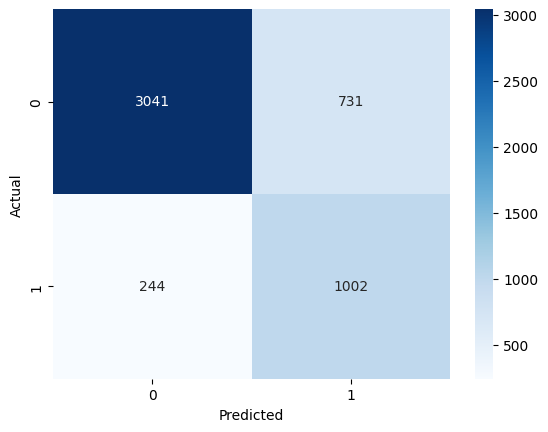

In [ ]:
prob_tree = check_model('Decision Tree', tree, X_bal, y_bal, X_test)

## 51. Draw the top of the tree

In [ ]:
from sklearn.tree import plot_tree

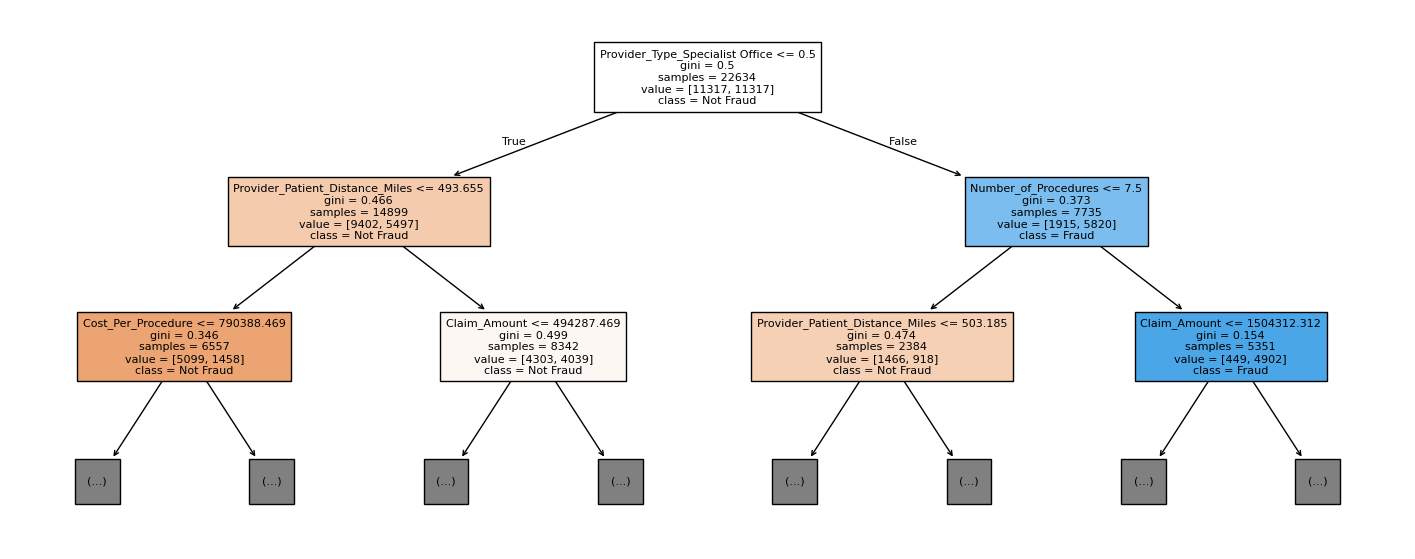

In [ ]:
plt.figure(figsize=(18, 7))
plot_tree(tree, max_depth=2, feature_names=X.columns,
          class_names=['Not Fraud', 'Fraud'], filled=True, fontsize=8)
plt.show()

## 52. Model 2 — Random ForestMany decision trees voting together. Usually better than one tree.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
forest = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

Random Forest
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      3772
           1       0.89      0.53      0.66      1246

    accuracy                           0.87      5018
   macro avg       0.88      0.75      0.79      5018
weighted avg       0.87      0.87      0.85      5018



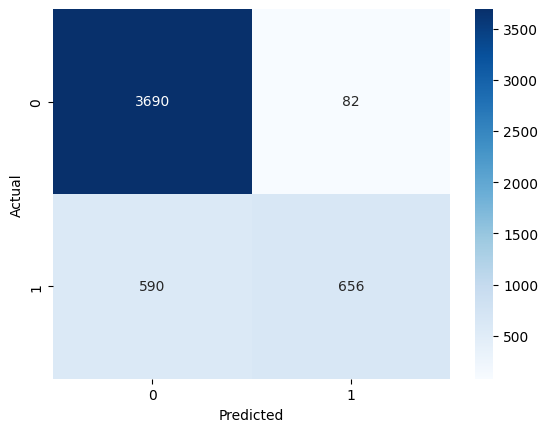

In [ ]:
prob_forest = check_model('Random Forest', forest, X_bal, y_bal, X_test)

## 53. Scale the data for KNN and SVMThese two models measure distance. Claim_Amount is in millions and Number_of_Procedures is 1 to 10, so without scaling only Claim_Amount would matter.

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

## 54. Fit the scaler on train, then apply it to both

In [ ]:
X_bal_scaled = scaler.fit_transform(X_bal)
X_test_scaled = scaler.transform(X_test)

## 55. Model 3 — KNNLooks at the 9 most similar claims and takes a vote.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=9)

KNN
              precision    recall  f1-score   support

           0       0.83      0.49      0.61      3772
           1       0.31      0.69      0.42      1246

    accuracy                           0.54      5018
   macro avg       0.57      0.59      0.52      5018
weighted avg       0.70      0.54      0.57      5018



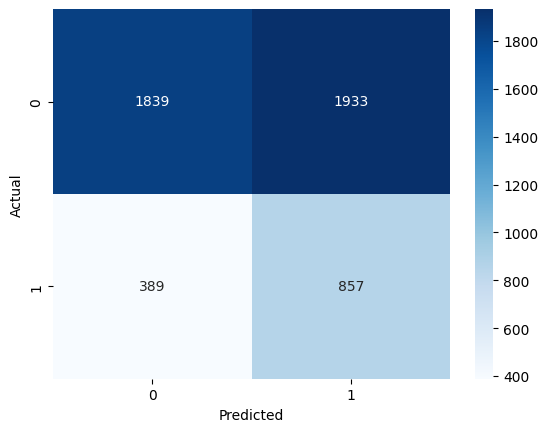

In [ ]:
prob_knn = check_model('KNN', knn, X_bal_scaled, y_bal, X_test_scaled)

## 56. Model 4 — XGBoostBuilds trees one after another, each fixing the mistakes of the last.

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,                    eval_metric='logloss', random_state=42)

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      3772
           1       0.70      0.67      0.68      1246

    accuracy                           0.85      5018
   macro avg       0.80      0.79      0.79      5018
weighted avg       0.84      0.85      0.85      5018



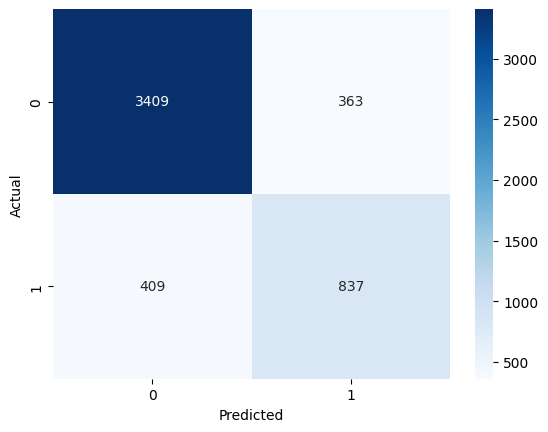

In [ ]:
prob_xgb = check_model('XGBoost', xgb, X_bal, y_bal, X_test)

## 57. Model 5 — SVMDraws a boundary between the two classes. It is slow, so we train on a sample of 4000 rows.

In [ ]:
from sklearn.svm import SVC

## 58. Take a sample of 4000 rows

In [ ]:
sample = X_bal.sample(4000, random_state=42)
y_sample = y_bal[sample.index]
sample_scaled = scaler.transform(sample)

In [ ]:
svm = SVC(probability=True, random_state=42)

SVM
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      3772
           1       0.57      0.65      0.60      1246

    accuracy                           0.79      5018
   macro avg       0.72      0.74      0.73      5018
weighted avg       0.80      0.79      0.79      5018



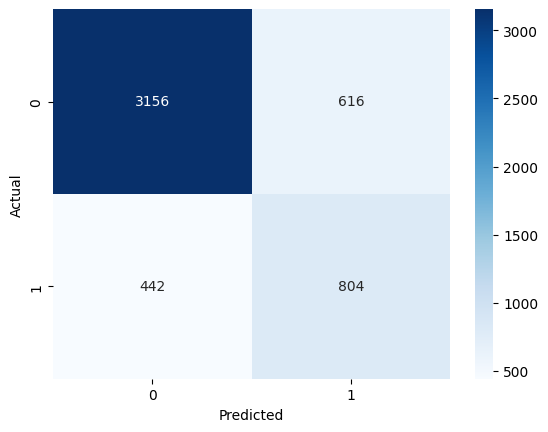

In [ ]:
prob_svm = check_model('SVM', svm, sample_scaled, y_sample, X_test_scaled)

## 59. Model 6 — Logistic RegressionThe simple statistical model. A good baseline to compare against.

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
logit = LogisticRegression(max_iter=2000)

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.77      0.82      3772
           1       0.50      0.71      0.59      1246

    accuracy                           0.75      5018
   macro avg       0.70      0.74      0.71      5018
weighted avg       0.79      0.75      0.77      5018



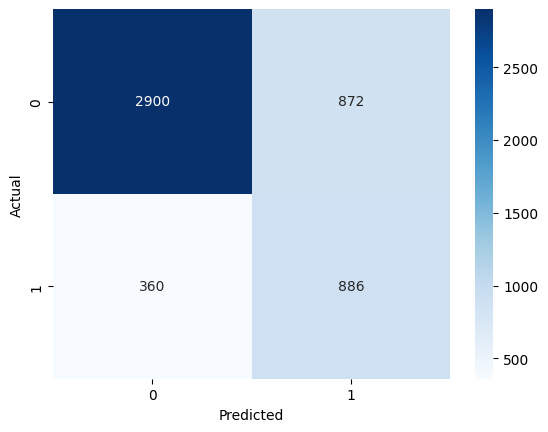

In [ ]:
prob_logit = check_model('Logistic Regression', logit, X_bal_scaled, y_bal, X_test_scaled)

## 60. Compare all six models

In [ ]:
comparison = pd.DataFrame(results).set_index('Model').sort_values('AUC', ascending=False)
comparison.round(3)

,Accuracy,Precision,Recall,F1,AUC
Model,,,,,
Random Forest,0.866,0.889,0.526,0.661,0.865
XGBoost,0.846,0.698,0.672,0.684,0.865
Decision Tree,0.806,0.578,0.804,0.673,0.845
SVM,0.789,0.566,0.645,0.603,0.811
Logistic Regression,0.754,0.504,0.711,0.590,0.810
KNN,0.537,0.307,0.688,0.425,0.646


## 61. Draw the ROC curves

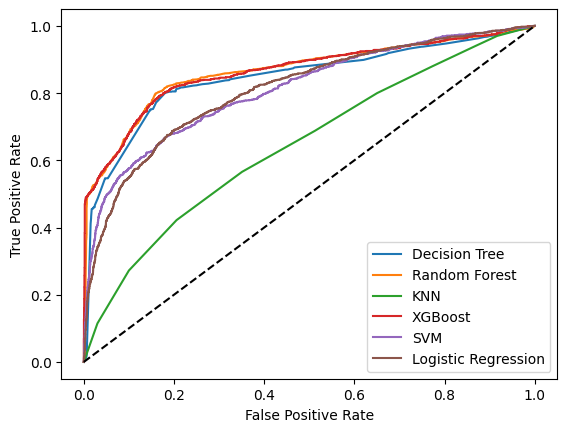

In [ ]:
plt.plot(*roc_curve(y_test, prob_tree)[:2], label='Decision Tree')
plt.plot(*roc_curve(y_test, prob_forest)[:2], label='Random Forest')
plt.plot(*roc_curve(y_test, prob_knn)[:2], label='KNN')
plt.plot(*roc_curve(y_test, prob_xgb)[:2], label='XGBoost')
plt.plot(*roc_curve(y_test, prob_svm)[:2], label='SVM')
plt.plot(*roc_curve(y_test, prob_logit)[:2], label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

Expect about 0.86 AUC for the tree models. That is a good score on this data. If you ever see 0.99, check for leakage.

## 62. Which features matter most?

In [ ]:
importance = pd.Series(forest.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
importance.head(15)

,0
Cost_Per_Procedure,0.083775
Number_of_Procedures,0.082698
Claim_Amount,0.082001
Provider_Type_Specialist Office,0.076234
Provider_Patient_Distance_Miles,0.072487
Deductible_Amount,0.031365
Days_To_Expiry,0.031314
CoPay_Amount,0.031112
Patient_Age,0.027760
Days_Service_To_Claim,0.027675


## 63. Plot the top 15

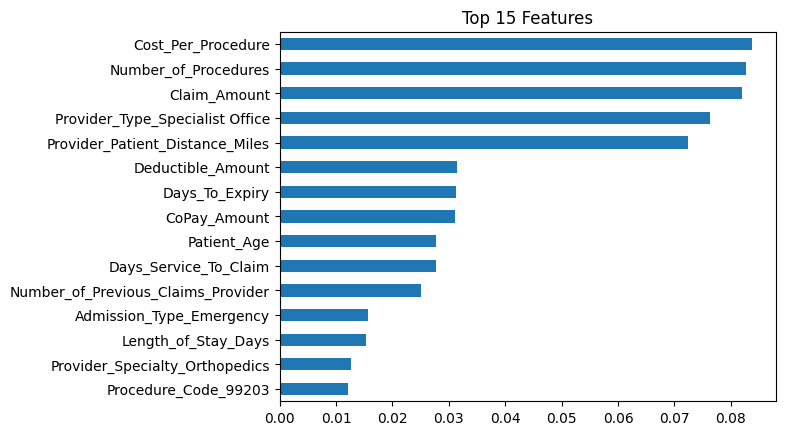

In [ ]:
importance.head(15).sort_values().plot(kind='barh')
plt.title('Top 15 Features')
plt.show()

## 64. Choose the cut-offBy default the model says fraud if the probability is above 0.5. A lower cut-off catches more fraud but raises more false alarms.

In [ ]:
rows = []

for cut in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    pred = (prob_forest >= cut).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({'Cut_off': cut,
                 'Alerts': tp + fp,
                 'Caught': tp,
                 'Missed': fn,
                 'Catch_Rate': round(tp / (tp + fn), 2),
                 'Precision': round(tp / (tp + fp), 2)})

## 65. Show the cut-off table

In [ ]:
pd.DataFrame(rows)

,Cut_off,Alerts,Caught,Missed,Catch_Rate,Precision
0,0.2,2121,1061,185,0.85,0.50
1,0.3,1595,994,252,0.80,0.62
2,0.4,1127,807,439,0.65,0.72
3,0.5,748,657,589,0.53,0.88
4,0.6,647,616,630,0.49,0.95
5,0.7,611,586,660,0.47,0.96
6,0.8,530,507,739,0.41,0.96


## 66. Conclusion**Best model:** XGBoost / Random Forest, about 0.87 AUC.**Main fraud indicators**1. Number of procedures and cost per procedure2. Specialist Office providers (50% fraud rate)3. Long patient-to-provider distance4. Cardiology and Orthopedics5. Elective and Urgent admissions**Recommendation:** use the model as a review queue, not an auto-reject. Pick the cut-off from step 64 based on what an investigation costs versus an average fraudulent payout.**Limitations:** the data is synthetic, patient claim history is missing, and no time-based testing was done.